# Linear Algebra Foundations for Quant Interviews

> *"Linear algebra is the language in which almost all of machine learning, statistics, and quantitative finance is written."*

This notebook builds the foundations **from first principles** — the way 3Blue1Brown would: pictures first, formulas second, intuition always. Every section is written with one eye on the **quant trading interview**, so whenever a concept shows up repeatedly on interview whiteboards, you'll see a callout like this:

> 🎯 **Quant interview alert:** this is the kind of thing they love to ask.

**Roadmap**

1. Notation & indexing — the grammar
2. Vector spaces — span, linear independence, basis, rank
3. Vector norms — L1 / L2 / Lp and their geometry
4. Matrix norms — Frobenius & spectral
5. Key matrix properties — trace, determinant, rank, condition number
6. Special matrix types — diagonal, symmetric, orthogonal, positive-definite, triangular
7. Summary table

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank, det, eig, eigvalsh, cond, svd

rng = np.random.default_rng(0)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]
np.set_printoptions(precision=3, suppress=True)
print("Setup complete. NumPy version:", np.__version__)

Setup complete. NumPy version: 2.4.6


## 1 · Notation & Indexing

Before we can reason about linear algebra, we need to agree on a **grammar**. Most interview confusion comes from sloppy notation, so let's nail it down.

### The three objects

| Object | Symbol | Example | Shape |
|---|---|---|---|
| Scalar | $a$ (lowercase, italic) | $a = 3$ | $(\;)$ |
| Vector | $\mathbf{x}$ (lowercase bold) | $\mathbf{x} = [x_1, x_2, x_3]^\top$ | $(n,)$ |
| Matrix | $\mathbf{A}$ (uppercase bold) | $\mathbf{A} \in \mathbb{R}^{m\times n}$ | $(m, n)$ |

**Indexing conventions** (the part everyone trips on):

- $A_{ij}$ = entry in **row $i$, column $j$**. Row first, always. Think "**R**oman **C**atholic" → **R**ow then **C**olumn.
- $\mathbf{a}_j$ (bold, single subscript) usually means the **$j$-th column** of $\mathbf{A}$.
- A vector $\mathbf{x} \in \mathbb{R}^n$ is by convention a **column** vector — an $n\times 1$ matrix. Its transpose $\mathbf{x}^\top$ is a row.

### The single most important shape rule

$$\underbrace{\mathbf{A}}_{m\times n}\;\underbrace{\mathbf{B}}_{n\times p} = \underbrace{\mathbf{C}}_{m\times p}$$

The **inner dimensions must match** ($n = n$) and they "cancel", leaving the **outer dimensions** as the result's shape. Read it as: *the columns of the left matrix must equal the rows of the right matrix.*

The entry $C_{ij}$ is the **dot product** of row $i$ of $\mathbf{A}$ with column $j$ of $\mathbf{B}$:

$$C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}$$

> **Key insight:** Matrix multiplication is just **dot products arranged in a grid**. Every single entry is one row meeting one column.

> 🎯 **Quant interview alert:** "What's the shape of $\mathbf{x}^\top \mathbf{A}\, \mathbf{x}$ if $\mathbf{x}\in\mathbb{R}^n$ and $\mathbf{A}\in\mathbb{R}^{n\times n}$?" Answer by cancelling dims: $(1\times n)(n\times n)(n\times 1) = (1\times 1)$ — a **scalar**. This object is a *quadratic form* and we'll meet it again in §6.

In [2]:
# Indexing in numpy: row first, column second
A = np.array([[1, 2, 3],
              [4, 5, 6]])          # shape (2, 3): 2 rows, 3 cols
print("A =\n", A, "\nshape:", A.shape)
print("A[0, 2] (row 0, col 2):", A[0, 2])   # -> 3
print("column j=1 (A[:, 1]):", A[:, 1])      # -> [2 5]
print("row i=1 (A[1, :]):", A[1, :])         # -> [4 5 6]

# The inner-dimension rule in action
B = np.array([[1, 0],
              [0, 1],
              [1, 1]])             # shape (3, 2)
C = A @ B                          # (2,3) @ (3,2) -> (2,2)
print("\n(2x3) @ (3x2) -> (2x2):\n", C)

# Verify one entry by hand: C[0,0] = row0(A) . col0(B)
manual = A[0, :] @ B[:, 0]
print("\nC[0,0] by hand (dot of row0, col0):", manual, "== C[0,0]:", C[0, 0])

# Quadratic form x^T A x -> scalar
x = np.array([1.0, 2.0])
S = np.array([[2.0, 0.5],
              [0.5, 1.0]])
print("\nx^T S x =", x @ S @ x, "(a scalar)")

A =
 [[1 2 3]
 [4 5 6]] 
shape: (2, 3)
A[0, 2] (row 0, col 2): 3
column j=1 (A[:, 1]): [2 5]
row i=1 (A[1, :]): [4 5 6]

(2x3) @ (3x2) -> (2x2):
 [[ 4  5]
 [10 11]]

C[0,0] by hand (dot of row0, col0): 4 == C[0,0]: 4

x^T S x = 8.0 (a scalar)


---
## 2 · Vector Spaces: Span, Linear Independence, Basis, Rank

This is the conceptual heart of linear algebra. If you internalise this section, half the subject becomes obvious.

### Linear combinations — the only operation that matters

Given vectors $\mathbf{v}_1, \dots, \mathbf{v}_k$ and scalars $c_1, \dots, c_k$, a **linear combination** is

$$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_k\mathbf{v}_k.$$

Think of each $\mathbf{v}_i$ as a *direction you can travel* and $c_i$ as *how far you go* in that direction. A linear combination is any destination reachable by walking along these directions.

### Span — everywhere you can reach

The **span** of a set of vectors is the set of **all** their linear combinations:

$$\text{span}(\mathbf{v}_1,\dots,\mathbf{v}_k) = \left\{ \textstyle\sum_i c_i \mathbf{v}_i \;\middle|\; c_i \in \mathbb{R} \right\}.$$

- One nonzero vector in $\mathbb{R}^2$ spans a **line**.
- Two vectors pointing in *different* directions span the **whole plane** $\mathbb{R}^2$.
- Two vectors pointing in the *same* direction still span only a **line** — the second one is redundant.

### Linear independence — no freeloaders

Vectors are **linearly independent** if the *only* way to combine them into the zero vector is the trivial way (all coefficients zero):

$$c_1\mathbf{v}_1 + \cdots + c_k\mathbf{v}_k = \mathbf{0} \quad\Longrightarrow\quad c_1 = \cdots = c_k = 0.$$

If some non-trivial combination gives $\mathbf{0}$, the vectors are **dependent** — at least one is a linear combination of the others and adds no new direction.

> **Key insight:** *Independent* = *every vector contributes a genuinely new direction.* *Dependent* = *at least one vector is redundant.*

### Basis & dimension

A **basis** of a space is a set of vectors that is (1) **linearly independent** and (2) **spans** the space. It's the *minimal* set of directions needed to reach everywhere — no redundancy, no gaps. The number of basis vectors is the **dimension**.

### Rank — the dimension of what a matrix can reach

The **rank** of a matrix $\mathbf{A}$ is the number of linearly independent columns (equivalently, rows — *row rank = column rank* always). It's the dimension of the **column space** (the span of the columns).

> 🎯 **Quant interview alert:** Rank questions are everywhere. "Is this matrix full rank?", "Is this matrix invertible?", "Are these factors collinear?" all reduce to rank. A square $n\times n$ matrix is **invertible $\iff$ rank $= n$ $\iff$ columns linearly independent $\iff$ $\det \neq 0$.** Memorise this chain of equivalences.

In [3]:
# Independent vs dependent sets in R^2
indep = np.array([[1, 0],
                  [0, 1]]).T        # columns: (1,0) and (0,1)
dep   = np.array([[1, 2],
                  [2, 4]]).T        # columns: (1,2) and (2,4)=2*(1,2)

print("Independent set -> rank:", matrix_rank(indep))   # 2: spans the plane
print("Dependent set   -> rank:", matrix_rank(dep))     # 1: spans only a line

# The dependency is exactly: 2*(1,2) - 1*(2,4) = 0  (non-trivial -> dependent)
print("2*v1 - 1*v2 =", 2*dep[:, 0] - dep[:, 1], "(zero -> dependent)")

Independent set -> rank: 2
Dependent set   -> rank: 1
2*v1 - 1*v2 = [0 0] (zero -> dependent)


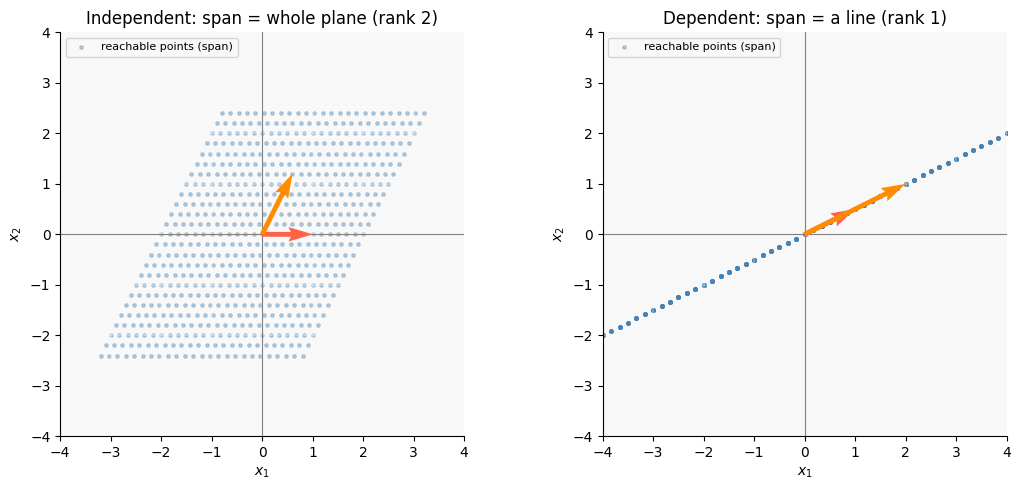

In [4]:
# Visualize span: independent pair fills the plane, dependent pair collapses to a line
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

def draw_span(ax, v1, v2, title):
    # sample many linear combinations c1*v1 + c2*v2
    cs = np.linspace(-2, 2, 25)
    pts = np.array([[a*v1[0] + b*v2[0], a*v1[1] + b*v2[1]]
                    for a in cs for b in cs])
    ax.scatter(pts[:, 0], pts[:, 1], s=6, color="steelblue", alpha=0.35,
               label="reachable points (span)")
    ax.quiver([0, 0], [0, 0], [v1[0], v2[0]], [v1[1], v2[1]],
              angles="xy", scale_units="xy", scale=1,
              color=["tomato", "darkorange"], width=0.012, zorder=5)
    ax.set(xlim=(-4, 4), ylim=(-4, 4), title=title, xlabel="$x_1$", ylabel="$x_2$")
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)

draw_span(axes[0], np.array([1, 0]), np.array([0.6, 1.2]),
          "Independent: span = whole plane (rank 2)")
draw_span(axes[1], np.array([1, 0.5]), np.array([2, 1.0]),
          "Dependent: span = a line (rank 1)")
plt.tight_layout(); plt.show()

Notice in the right panel: even though we have *two* vectors, every reachable point lies on a single line. The second vector is a scalar multiple of the first, so it adds **no new direction** — the span collapses from 2D to 1D. That collapse is exactly what "rank 1" means.

---
## 3 · Vector Norms: Measuring Length

A **norm** $\|\cdot\|$ is a function that assigns a non-negative "length" to a vector. Formally it must satisfy three axioms (worth knowing for interviews):

1. **Non-negativity:** $\|\mathbf{x}\| \ge 0$, and $= 0$ only when $\mathbf{x}=\mathbf{0}$.
2. **Homogeneity:** $\|c\,\mathbf{x}\| = |c|\,\|\mathbf{x}\|$ (scaling the vector scales its length).
3. **Triangle inequality:** $\|\mathbf{x}+\mathbf{y}\| \le \|\mathbf{x}\| + \|\mathbf{y}\|$ (a detour is never shorter).

### The $L_p$ family

$$\|\mathbf{x}\|_p = \left( \sum_{i=1}^{n} |x_i|^p \right)^{1/p}, \qquad p \ge 1.$$

Read the formula as: *raise each coordinate's magnitude to the power $p$, add them up, then take the $p$-th root to undo the power.* The choice of $p$ controls **how much big coordinates dominate**.

| Norm | Formula | Nickname | Picture |
|---|---|---|---|
| $L_1$ | $\sum_i |x_i|$ | Manhattan / taxicab | diamond |
| $L_2$ | $\sqrt{\sum_i x_i^2}$ | Euclidean (straight-line) | circle |
| $L_\infty$ | $\max_i |x_i|$ | Chebyshev / max | square |

- **$L_1$ (Manhattan):** distance if you can only walk along grid streets. Used in **Lasso** regression because it produces **sparse** solutions (drives coefficients to exactly 0).
- **$L_2$ (Euclidean):** ordinary straight-line distance — the one your geometric intuition uses. Used in **Ridge** regression and almost everywhere else.
- **$L_\infty$:** as $p\to\infty$ the largest coordinate swallows the sum, so the norm becomes just the max.

> **Key insight:** The **unit ball** $\{\mathbf{x} : \|\mathbf{x}\| \le 1\}$ has a different *shape* for each norm. That shape is *why* $L_1$ gives sparsity: its pointy corners sit on the axes, so optimisation solutions tend to land on them (where coordinates are zero).

> 🎯 **Quant interview alert:** "Why does $L_1$ regularisation induce sparsity but $L_2$ doesn't?" — answer with the geometry of the diamond vs the circle: the diamond's corners lie *on the axes*, the circle's boundary is smooth so it almost never touches an axis exactly.

In [5]:
x = np.array([3.0, -4.0])
print("x =", x)
print("L1 norm  (sum |xi|)      :", norm(x, 1))      # 3 + 4 = 7
print("L2 norm  (sqrt sum xi^2) :", norm(x, 2))      # sqrt(9+16) = 5
print("Linf norm (max |xi|)     :", norm(x, np.inf)) # max(3,4) = 4

# Watch p interpolate from L1 to Linf
for p in [1, 1.5, 2, 4, 10, 100]:
    print(f"  ||x||_{p:<5} = {norm(x, p):.4f}")
print("  ||x||_inf  =", norm(x, np.inf), "(the limit as p -> infinity)")

x = [ 3. -4.]
L1 norm  (sum |xi|)      : 7.0
L2 norm  (sqrt sum xi^2) : 5.0
Linf norm (max |xi|)     : 4.0
  ||x||_1     = 7.0000
  ||x||_1.5   = 5.5843
  ||x||_2     = 5.0000
  ||x||_4     = 4.2846
  ||x||_10    = 4.0220
  ||x||_100   = 4.0000
  ||x||_inf  = 4.0 (the limit as p -> infinity)


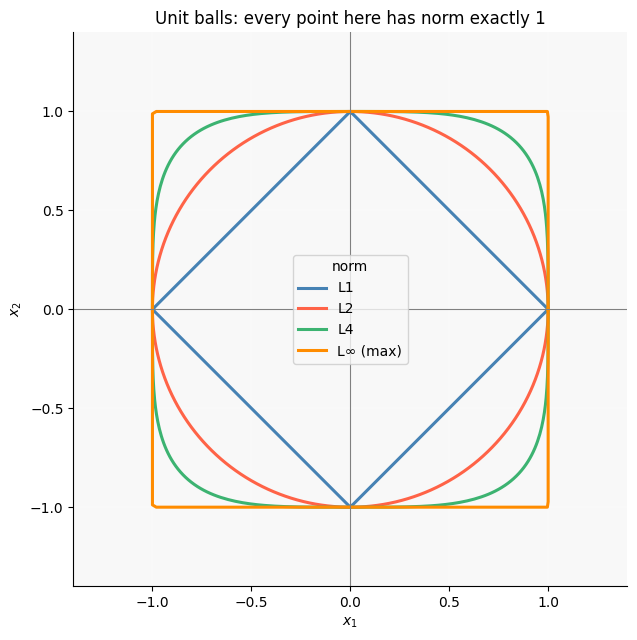

L1 = diamond (corners ON the axes -> sparsity)
L2 = circle  (smooth, no special directions)
Linf = square (corners on the diagonals)


In [6]:
# Draw the unit balls {x : ||x||_p = 1} for several p
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])   # directions around the unit circle

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for p, c in zip([1, 2, 4, np.inf], PALETTE):
    # scale each direction so its p-norm is exactly 1
    pnorms = norm(circle, p, axis=0)
    unit = circle / pnorms
    label = "L∞ (max)" if np.isinf(p) else f"L{p}"
    ax.plot(unit[0], unit[1], color=c, lw=2.2, label=label)

ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4),
       title="Unit balls: every point here has norm exactly 1",
       xlabel="$x_1$", ylabel="$x_2$")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(title="norm")
plt.tight_layout(); plt.show()
print("L1 = diamond (corners ON the axes -> sparsity)")
print("L2 = circle  (smooth, no special directions)")
print("Linf = square (corners on the diagonals)")

---
## 4 · Matrix Norms: Measuring the "Size" of a Matrix

How big is a matrix? There are two useful answers, and they measure *different things*.

### 4.1 Frobenius norm — treat the matrix as a long vector

$$\|\mathbf{A}\|_F = \sqrt{\sum_{i,j} A_{ij}^2} = \sqrt{\operatorname{tr}(\mathbf{A}^\top \mathbf{A})}.$$

Just flatten the matrix into one big vector and take its $L_2$ norm. It measures **total energy / overall magnitude** of all entries. Simple, cheap, and the default for "how far apart are two matrices" (e.g. $\|\mathbf{A}-\hat{\mathbf{A}}\|_F$ in low-rank approximation).

### 4.2 Spectral norm — the maximum stretch

The **spectral norm** (a.k.a. operator 2-norm) measures the *most* a matrix can stretch any unit vector:

$$\|\mathbf{A}\|_2 = \max_{\|\mathbf{x}\|_2 = 1} \|\mathbf{A}\mathbf{x}\|_2 = \sigma_{\max}(\mathbf{A}),$$

where $\sigma_{\max}$ is the **largest singular value** of $\mathbf{A}$. Picture feeding every unit vector (every point on the unit circle) through $\mathbf{A}$: the output is an ellipse, and the spectral norm is the **length of its longest semi-axis** — the worst-case amplification.

> **Key insight:** Frobenius asks *"how much stuff is in the matrix?"* (a sum over entries). Spectral asks *"what is the worst-case stretch this matrix applies to a direction?"* (a max over inputs). They answer different questions.

A useful relationship, with $r = \text{rank}$ and $\sigma_i$ the singular values:

$$\|\mathbf{A}\|_F = \sqrt{\textstyle\sum_i \sigma_i^2}, \qquad \|\mathbf{A}\|_2 = \sigma_{\max}, \qquad \|\mathbf{A}\|_2 \le \|\mathbf{A}\|_F \le \sqrt{r}\,\|\mathbf{A}\|_2.$$

> 🎯 **Quant interview alert:** The spectral norm = largest singular value = $\sqrt{\lambda_{\max}(\mathbf{A}^\top\mathbf{A})}$ shows up constantly in stability, PCA, and condition-number questions. Know that for a **symmetric** matrix, singular values are $|\lambda_i|$, so $\|\mathbf{A}\|_2 = \max_i |\lambda_i|$.

In [7]:
A = np.array([[2.0, 1.0],
              [0.0, 3.0]])

fro = norm(A, "fro")
spec = norm(A, 2)
sing = svd(A, compute_uv=False)

print("A =\n", A)
print("\nSingular values:", sing)
print("Frobenius ||A||_F      :", fro, " == sqrt(sum sigma^2):", np.sqrt((sing**2).sum()))
print("Spectral  ||A||_2      :", spec, " == sigma_max:", sing.max())
print("Check inequality ||A||_2 <= ||A||_F:", spec <= fro + 1e-9)

A =
 [[2. 1.]
 [0. 3.]]

Singular values: [3.257 1.842]
Frobenius ||A||_F      : 3.7416573867739413  == sqrt(sum sigma^2): 3.741657386773941
Spectral  ||A||_2      : 3.2566165379829393  == sigma_max: 3.2566165379829393
Check inequality ||A||_2 <= ||A||_F: True


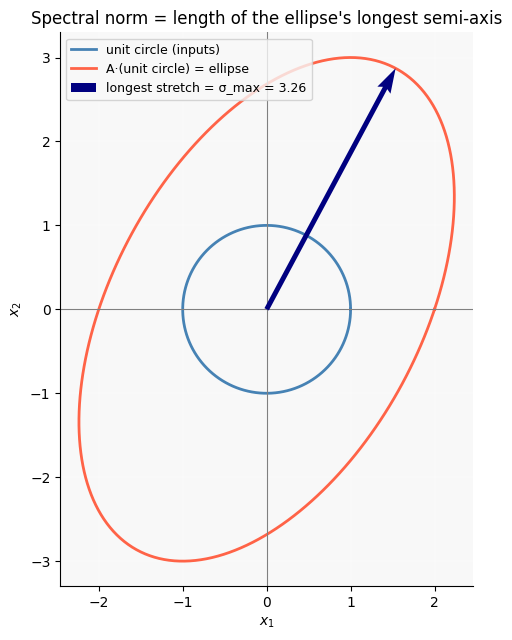

In [8]:
# Spectral norm visualised: the unit circle maps to an ellipse; ||A||_2 is its longest semi-axis
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse = A @ circle

# longest output direction = left singular vector u1 scaled by sigma_max
U, S, Vt = svd(A)
long_axis = U[:, 0] * S[0]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(circle[0], circle[1], color="steelblue", lw=2, label="unit circle (inputs)")
ax.plot(ellipse[0], ellipse[1], color="tomato", lw=2, label="A·(unit circle) = ellipse")
ax.quiver(0, 0, long_axis[0], long_axis[1], angles="xy", scale_units="xy", scale=1,
          color="navy", width=0.012, zorder=5,
          label=f"longest stretch = σ_max = {S[0]:.2f}")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set(title="Spectral norm = length of the ellipse's longest semi-axis",
       xlabel="$x_1$", ylabel="$x_2$")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

---
## 5 · Key Matrix Properties: Trace, Determinant, Rank, Condition Number

These four numbers summarise a matrix's most important behaviours.

### 5.1 Trace — the sum of the diagonal

$$\operatorname{tr}(\mathbf{A}) = \sum_{i=1}^n A_{ii} = \sum_{i=1}^n \lambda_i.$$

The trace equals the **sum of the eigenvalues**. Two facts interviewers love:
- **Cyclic property:** $\operatorname{tr}(\mathbf{ABC}) = \operatorname{tr}(\mathbf{BCA}) = \operatorname{tr}(\mathbf{CAB})$ — you can rotate the product (not arbitrarily reorder!).
- A neat consequence: $\operatorname{tr}(\mathbf{AB}) = \operatorname{tr}(\mathbf{BA})$ even when $\mathbf{AB}$ and $\mathbf{BA}$ have different shapes.

### 5.2 Determinant — the volume scaling factor

$$\det(\mathbf{A}) = \prod_{i=1}^n \lambda_i.$$

The determinant equals the **product of the eigenvalues**, and geometrically it is the **factor by which $\mathbf{A}$ scales volume** (area in 2D). Read its value like this:
- $|\det| > 1$: the transformation **expands** space.
- $|\det| < 1$: it **shrinks** space.
- $\det = 0$: space is **squashed flat** into a lower dimension → matrix is **singular** (non-invertible, columns dependent, rank deficient).
- $\det < 0$: orientation is **flipped** (like a mirror).

Useful identities: $\det(\mathbf{AB}) = \det(\mathbf{A})\det(\mathbf{B})$ and $\det(\mathbf{A}^{-1}) = 1/\det(\mathbf{A})$.

### 5.3 Condition number — how much errors get amplified

$$\kappa(\mathbf{A}) = \|\mathbf{A}\|_2 \,\|\mathbf{A}^{-1}\|_2 = \frac{\sigma_{\max}}{\sigma_{\min}}.$$

It's the ratio of the **biggest stretch to the smallest stretch**. When you solve $\mathbf{A}\mathbf{x}=\mathbf{b}$, the condition number bounds how much a small error in $\mathbf{b}$ can blow up in $\mathbf{x}$:
- $\kappa \approx 1$: **well-conditioned** — stable, errors stay small.
- $\kappa \gg 1$: **ill-conditioned** — tiny input noise causes huge output swings. The ellipse from §4 is a long thin sliver.
- $\kappa = \infty$: singular.

> **Key insight:** Determinant tells you *if* a matrix is invertible (zero or not). Condition number tells you *how dangerous* the inversion is **numerically** — a matrix can have a perfectly nonzero determinant yet be a nightmare to invert.

> 🎯 **Quant interview alert:** This is gold for trading. A **covariance matrix of highly correlated assets** is ill-conditioned (κ huge): the near-collinear columns make $\sigma_{\min}\to 0$. Inverting it (e.g. for Markowitz portfolio weights $\mathbf{w} \propto \Sigma^{-1}\boldsymbol\mu$) then amplifies noise and produces wildly unstable, leveraged positions. That's the practical motivation for **shrinkage / regularisation** of covariance matrices.

In [9]:
A = np.array([[2.0, 1.0],
              [1.0, 3.0]])
vals = eigvalsh(A)   # symmetric -> real eigenvalues

print("A =\n", A)
print("\nEigenvalues:", vals)
print("trace(A)      :", np.trace(A), " == sum(eigs):", vals.sum())
print("det(A)        :", det(A),      " == prod(eigs):", vals.prod())
print("rank(A)       :", matrix_rank(A))
print("cond(A) = κ   :", cond(A), " == σ_max/σ_min:", svd(A, compute_uv=False).max()/svd(A, compute_uv=False).min())

# Cyclic property of trace
B = rng.standard_normal((2, 3)); Cmat = rng.standard_normal((3, 2))
print("\ntr(BC) =", np.trace(B @ Cmat), " == tr(CB) =", np.trace(Cmat @ B), "(different shapes inside!)")

A =
 [[2. 1.]
 [1. 3.]]

Eigenvalues: [1.382 3.618]
trace(A)      : 5.0  == sum(eigs): 5.0
det(A)        : 5.000000000000001  == prod(eigs): 5.0
rank(A)       : 2
cond(A) = κ   : 2.6180339887498953  == σ_max/σ_min: 2.6180339887498953

tr(BC) = 0.6498996777845545  == tr(CB) = 0.6498996777845545 (different shapes inside!)


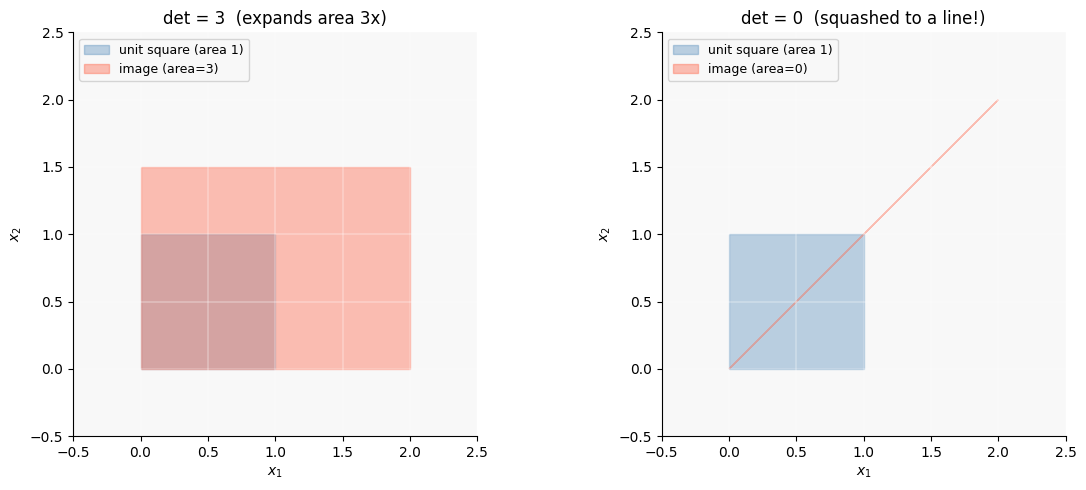

In [10]:
# Determinant as area scaling: unit square -> parallelogram, area = |det|
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
unit_sq = np.array([[0, 1, 1, 0, 0],
                    [0, 0, 1, 1, 0]])

for ax, M, name in zip(axes,
                       [np.array([[2.0, 0.0], [0.0, 1.5]]),
                        np.array([[1.0, 1.0], [1.0, 1.0]])],
                       ["det = 3  (expands area 3x)", "det = 0  (squashed to a line!)"]):
    out = M @ unit_sq
    ax.fill(unit_sq[0], unit_sq[1], color="steelblue", alpha=0.35, label="unit square (area 1)")
    ax.fill(out[0], out[1], color="tomato", alpha=0.4, label=f"image (area={abs(det(M)):.0f})")
    ax.set(title=name, xlabel="$x_1$", ylabel="$x_2$", xlim=(-0.5, 2.5), ylim=(-0.5, 2.5))
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

In [11]:
# Condition number in action: well- vs ill-conditioned, and why it matters for inversion
well = np.array([[1.0, 0.0],
                 [0.0, 1.0]])              # κ = 1
ill  = np.array([[1.0, 0.999],
                 [0.999, 1.0]])            # nearly collinear rows -> κ huge

print("κ(well-conditioned identity):", cond(well))
print("κ(ill-conditioned, ρ≈0.999) :", cond(ill))

# Demonstrate error amplification when solving Ax = b
b = np.array([1.0, 1.0])
db = np.array([0.001, -0.001])             # tiny perturbation in b
for M, name in [(well, "well"), (ill, "ill")]:
    x  = np.linalg.solve(M, b)
    xp = np.linalg.solve(M, b + db)
    rel_in  = norm(db) / norm(b)
    rel_out = norm(xp - x) / norm(x)
    print(f"  [{name:>4}] input error {rel_in:.2%}  ->  output error {rel_out:.2%}"
          f"  (amplified {rel_out/rel_in:.1f}x)")

κ(well-conditioned identity): 1.0
κ(ill-conditioned, ρ≈0.999) : 1999.0000000000025
  [well] input error 0.10%  ->  output error 0.10%  (amplified 1.0x)
  [ ill] input error 0.10%  ->  output error 199.90%  (amplified 1999.0x)


Look at that last output: in the ill-conditioned matrix a **0.1% wiggle in the input** balloons into a far larger error in the solution. That is precisely why correlated-asset covariance matrices are dangerous to invert.

---
## 6 · Special Matrix Types

Certain matrix structures appear so often that they have names — and recognising them instantly is a big interview advantage, because each structure unlocks shortcuts.

### 6.1 Diagonal — $\mathbf{D}$, zeros off the diagonal
Multiplying by a diagonal matrix just **scales each coordinate independently**. Its eigenvalues, determinant ($\prod d_{ii}$), and inverse ($1/d_{ii}$) are all trivial to read off.

### 6.2 Symmetric — $\mathbf{A} = \mathbf{A}^\top$
The single most important class in ML/finance (covariance matrices, kernels, Hessians are all symmetric). The **Spectral Theorem** guarantees:
- all eigenvalues are **real**, and
- eigenvectors can be chosen **orthonormal**, giving $\mathbf{A} = \mathbf{Q}\boldsymbol\Lambda\mathbf{Q}^\top$ (orthogonal $\mathbf{Q}$, diagonal $\boldsymbol\Lambda$).

### 6.3 Orthogonal — $\mathbf{Q}^\top\mathbf{Q} = \mathbf{I}$, i.e. $\mathbf{Q}^{-1} = \mathbf{Q}^\top$
Columns are **orthonormal** (mutually perpendicular, unit length). Orthogonal matrices are **rigid motions** — rotations and reflections. They **preserve lengths and angles**: $\|\mathbf{Q}\mathbf{x}\|_2 = \|\mathbf{x}\|_2$. Their eigenvalues all have $|\lambda| = 1$, $\det = \pm 1$, and $\kappa = 1$ (perfectly conditioned).

### 6.4 Positive-definite (PD) — $\mathbf{x}^\top\mathbf{A}\mathbf{x} > 0$ for all $\mathbf{x} \neq \mathbf{0}$
A *symmetric* matrix is PD iff **all eigenvalues are strictly positive** (positive *semi*-definite, PSD, allows $\ge 0$). Geometrically the quadratic form $\mathbf{x}^\top\mathbf{A}\mathbf{x}$ is a **bowl that curves upward in every direction** — it has a unique minimum, which is why PD Hessians mean convex problems with a single optimum.

### 6.5 Triangular — all zeros above (lower) or below (upper) the diagonal
Eigenvalues = the diagonal entries (free!). Systems solve in one sweep via **back/forward substitution** — the engine behind LU and Cholesky factorisations.

> **Key insight:** Every covariance matrix is **symmetric PSD** by construction. If it's also full rank (no perfectly redundant assets) it is **PD**, hence invertible — the precondition for mean-variance portfolio optimisation.

> 🎯 **Quant interview alert:** PD/PSD is *the* most-tested matrix concept in quant. Be ready to (1) define it three ways — quadratic form $> 0$, all eigenvalues $> 0$, all leading principal minors $> 0$ (Sylvester's criterion); (2) explain why covariance matrices are PSD ($\mathbf{x}^\top\Sigma\mathbf{x} = \operatorname{Var}(\mathbf{x}^\top\mathbf{r}) \ge 0$ — a variance can't be negative!); and (3) know that the **Cholesky decomposition** $\Sigma = \mathbf{L}\mathbf{L}^\top$ exists iff $\Sigma$ is PD, and is the standard way to generate correlated Gaussian returns in Monte-Carlo simulations.

In [12]:
# 6.2 Symmetric: eigenvalues real, eigenvectors orthonormal (Spectral Theorem)
S = np.array([[2.0, 1.0],
              [1.0, 2.0]])
w, Q = eig(S)
print("Symmetric S eigenvalues (all real):", w.real)
print("Eigenvectors orthonormal? Q^T Q =\n", (Q.T @ Q).round(6))
print("Reconstruct S = Q Λ Q^T:\n", (Q @ np.diag(w) @ Q.T).real)

# 6.3 Orthogonal: rotation preserves length
t = np.deg2rad(40)
Qrot = np.array([[np.cos(t), -np.sin(t)],
                 [np.sin(t),  np.cos(t)]])
v = np.array([3.0, 1.0])
print("\nOrthogonal check Q^T Q = I:\n", (Qrot.T @ Qrot).round(6))
print("||v|| =", norm(v), " ||Q v|| =", norm(Qrot @ v), "(length preserved)")
print("det(Q) =", round(det(Qrot), 6), " (=+1 -> pure rotation)")

Symmetric S eigenvalues (all real): [3. 1.]
Eigenvectors orthonormal? Q^T Q =
 [[1. 0.]
 [0. 1.]]
Reconstruct S = Q Λ Q^T:
 [[2. 1.]
 [1. 2.]]

Orthogonal check Q^T Q = I:
 [[1. 0.]
 [0. 1.]]
||v|| = 3.1622776601683795  ||Q v|| = 3.162277660168379 (length preserved)
det(Q) = 1.0  (=+1 -> pure rotation)


In [13]:
# 6.4 Positive-definite test + Cholesky (the quant workhorse)
def classify(M):
    ev = eigvalsh(M)
    if np.all(ev > 1e-12):  return "Positive-Definite (all λ > 0)"
    if np.all(ev >= -1e-12): return "Positive-Semi-Definite (all λ ≥ 0)"
    return "Indefinite (mixed-sign λ)"

PD  = np.array([[2.0, 0.5], [0.5, 1.0]])
IND = np.array([[1.0, 2.0], [2.0, 1.0]])
for M, nm in [(PD, "PD matrix"), (IND, "Indefinite matrix")]:
    print(f"{nm}: eigenvalues {eigvalsh(M)}  ->  {classify(M)}")

# Cholesky exists only for PD matrices: Σ = L L^T
L = np.linalg.cholesky(PD)
print("\nCholesky factor L (lower-triangular):\n", L)
print("L @ L^T reconstructs PD:\n", L @ L.T)
try:
    np.linalg.cholesky(IND)
except np.linalg.LinAlgError as e:
    print("\nCholesky on indefinite matrix fails:", e)

PD matrix: eigenvalues [0.793 2.207]  ->  Positive-Definite (all λ > 0)
Indefinite matrix: eigenvalues [-1.  3.]  ->  Indefinite (mixed-sign λ)

Cholesky factor L (lower-triangular):
 [[1.414 0.   ]
 [0.354 0.935]]
L @ L^T reconstructs PD:
 [[2.  0.5]
 [0.5 1. ]]

Cholesky on indefinite matrix fails: Matrix is not positive definite


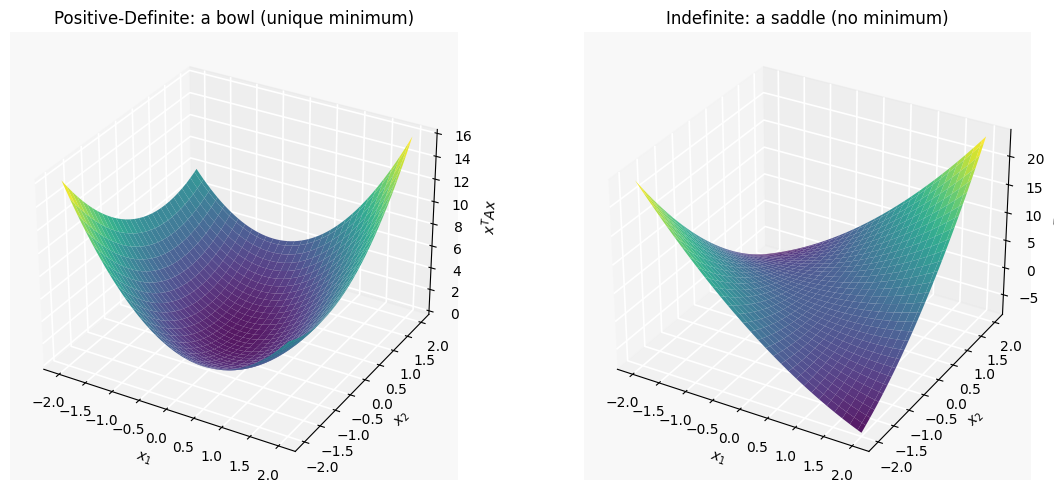

PD -> convex bowl -> gradient descent finds THE minimum.
Indefinite -> saddle -> no global min; optimisation can run away.


In [14]:
# Visualize the quadratic form x^T A x: PD = upward bowl, indefinite = saddle
g = np.linspace(-2, 2, 60)
X, Y = np.meshgrid(g, g)

fig = plt.figure(figsize=(12, 5))
for k, (M, title) in enumerate([(PD, "Positive-Definite: a bowl (unique minimum)"),
                                (IND, "Indefinite: a saddle (no minimum)")]):
    Z = M[0,0]*X**2 + (M[0,1]+M[1,0])*X*Y + M[1,1]*Y**2
    ax = fig.add_subplot(1, 2, k+1, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.9, linewidth=0)
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$", zlabel="$x^T A x$")
plt.tight_layout(); plt.show()
print("PD -> convex bowl -> gradient descent finds THE minimum.")
print("Indefinite -> saddle -> no global min; optimisation can run away.")

### Interactive: build your own 2×2 symmetric matrix and watch its character change

Drag the sliders to set the entries of a symmetric matrix $\mathbf{A} = \begin{bmatrix} a & b \\ b & c\end{bmatrix}$. Watch how its **eigenvalues**, **definiteness**, **determinant**, and **condition number** respond — and how the unit circle gets stretched into an ellipse. This single widget ties together §3–§6.

*(If `ipywidgets` isn't installed, the static fallback below still runs.)*

In [15]:
def show_matrix(a=2.0, b=0.5, c=1.0):
    A = np.array([[a, b], [b, c]])
    ev = eigvalsh(A)
    if np.all(ev > 0):      kind = "Positive-Definite ✅ (bowl, invertible)"
    elif np.all(ev >= 0):   kind = "Positive-Semi-Definite (flat direction)"
    elif np.all(ev < 0):    kind = "Negative-Definite"
    else:                   kind = "Indefinite (saddle)"
    kappa = cond(A) if np.all(np.abs(ev) > 1e-9) else np.inf

    theta = np.linspace(0, 2*np.pi, 300)
    circ = np.vstack([np.cos(theta), np.sin(theta)])
    out = A @ circ
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot(circ[0], circ[1], color="steelblue", lw=1.8, label="unit circle")
    ax.plot(out[0], out[1], color="tomato", lw=2, label="A·circle")
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
    ax.set(title=f"λ={ev.round(2)}  det={det(A):.2f}  κ={kappa:.1f}\n{kind}",
           xlabel="$x_1$", ylabel="$x_2$", xlim=(-4, 4), ylim=(-4, 4))
    plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(show_matrix,
             a=FloatSlider(2.0, min=-2, max=4, step=0.25, description="a"),
             b=FloatSlider(0.5, min=-3, max=3, step=0.25, description="b"),
             c=FloatSlider(1.0, min=-2, max=4, step=0.25, description="c"))
except ImportError:
    print("ipywidgets not available — showing a static example instead.")
    show_matrix()

interactive(children=(FloatSlider(value=2.0, description='a', max=4.0, min=-2.0, step=0.25), FloatSlider(value…

---
## 7 · Summary

| Concept | Key Idea |
|---|---|
| **Indexing** $A_{ij}$ | Row $i$, column $j$. Matrix mult: inner dims match, $C_{ij}$ = row·column dot product. |
| **Span** | All linear combinations of a set of vectors — everywhere you can reach. |
| **Linear independence** | No vector is redundant; only the trivial combo gives $\mathbf{0}$. |
| **Basis / dimension** | Minimal independent set that spans the space; its size = dimension. |
| **Rank** | # independent columns (= rows) = dimension of column space. Full rank ⇔ invertible ⇔ $\det\neq0$. |
| **$L_1$ norm** | $\sum|x_i|$, diamond ball, induces **sparsity** (Lasso). |
| **$L_2$ norm** | $\sqrt{\sum x_i^2}$, circular ball, ordinary Euclidean length (Ridge). |
| **$L_\infty$ norm** | $\max|x_i|$, square ball. |
| **Frobenius norm** | $\sqrt{\sum A_{ij}^2}$ — matrix as a flattened vector; total energy. |
| **Spectral norm** | $\sigma_{\max}$ — worst-case stretch; longest ellipse axis. |
| **Trace** | $\sum A_{ii} = \sum\lambda_i$; cyclic: $\operatorname{tr}(AB)=\operatorname{tr}(BA)$. |
| **Determinant** | $\prod\lambda_i$ = signed volume scaling; $\det=0$ ⇔ singular. |
| **Condition number** | $\sigma_{\max}/\sigma_{\min}$ = error amplification; huge for correlated assets. |
| **Diagonal** | Scales coordinates independently; trivial inverse/det. |
| **Symmetric** | $A=A^\top$; real eigenvalues, orthonormal eigenvectors (Spectral Theorem). |
| **Orthogonal** | $Q^\top Q=I$; rotations/reflections, preserve length, $\kappa=1$. |
| **Positive-definite** | $\mathbf{x}^\top A\mathbf{x}>0$ ⇔ all $\lambda>0$; upward bowl; covariance matrices live here. |
| **Triangular** | Eigenvalues on diagonal; solved by substitution (LU, Cholesky). |

### 🎯 Top interview takeaways

1. **The invertibility chain:** full rank ⇔ independent columns ⇔ $\det \neq 0$ ⇔ nonzero eigenvalues. Recite it cold.
2. **PD/PSD is king.** Define it three ways; explain why covariance matrices are PSD (a variance ≥ 0); connect to Cholesky for simulating correlated returns.
3. **Condition number → portfolio instability.** Correlated assets ⇒ ill-conditioned $\Sigma$ ⇒ noisy, blown-up $\Sigma^{-1}\boldsymbol\mu$ weights ⇒ motivates shrinkage.
4. **$L_1$ vs $L_2$ geometry** explains sparsity — draw the diamond and the circle.
5. **Spectral norm = $\sigma_{\max}$**, and for symmetric matrices $=\max_i|\lambda_i|$.

*You now have the vocabulary and the geometric intuition that the rest of quantitative finance and ML is built on.*